### Ноутбук расчетов альтернативной спецификации с ИО HtM ДХ

Это pandas DataFrame!
Это pandas DataFrame!


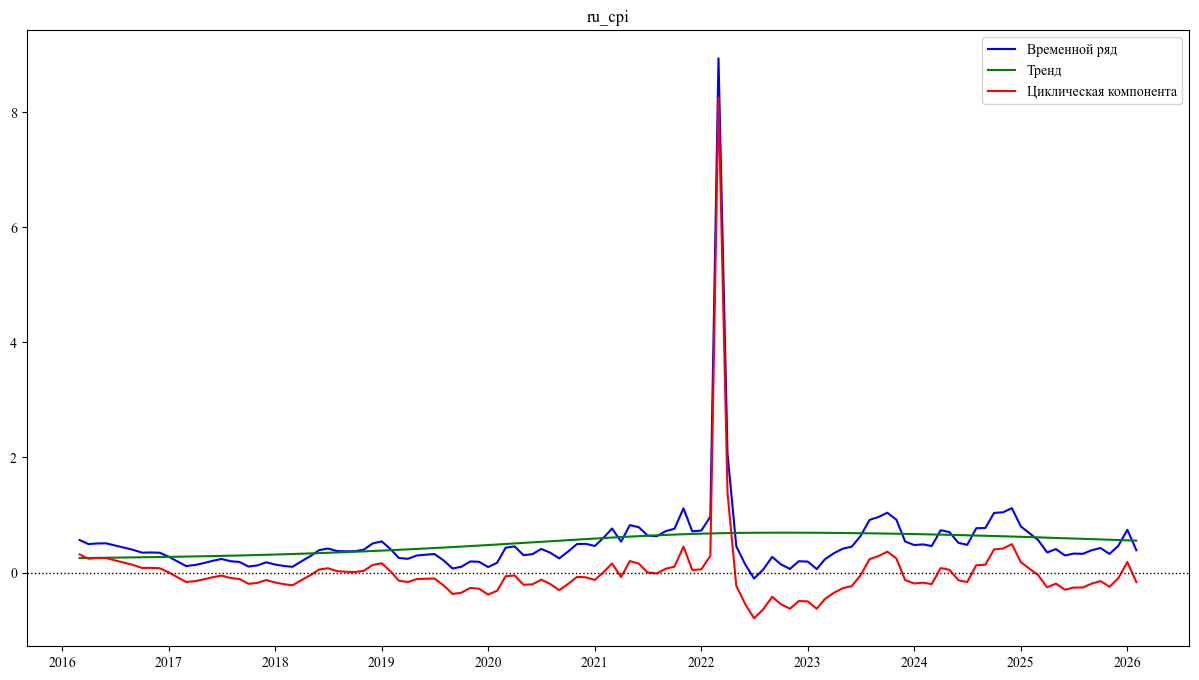

Исходный ряд ru_cpi оказался стационарным


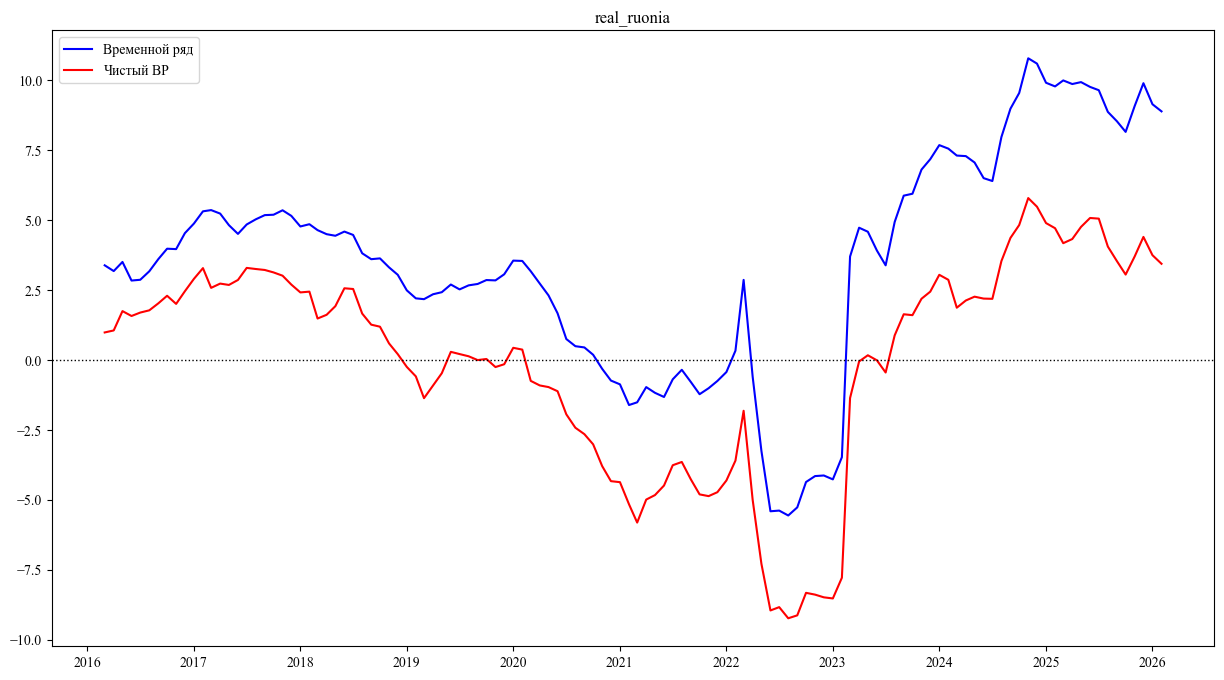

Исходный ряд real_ruonia оказался стационарным


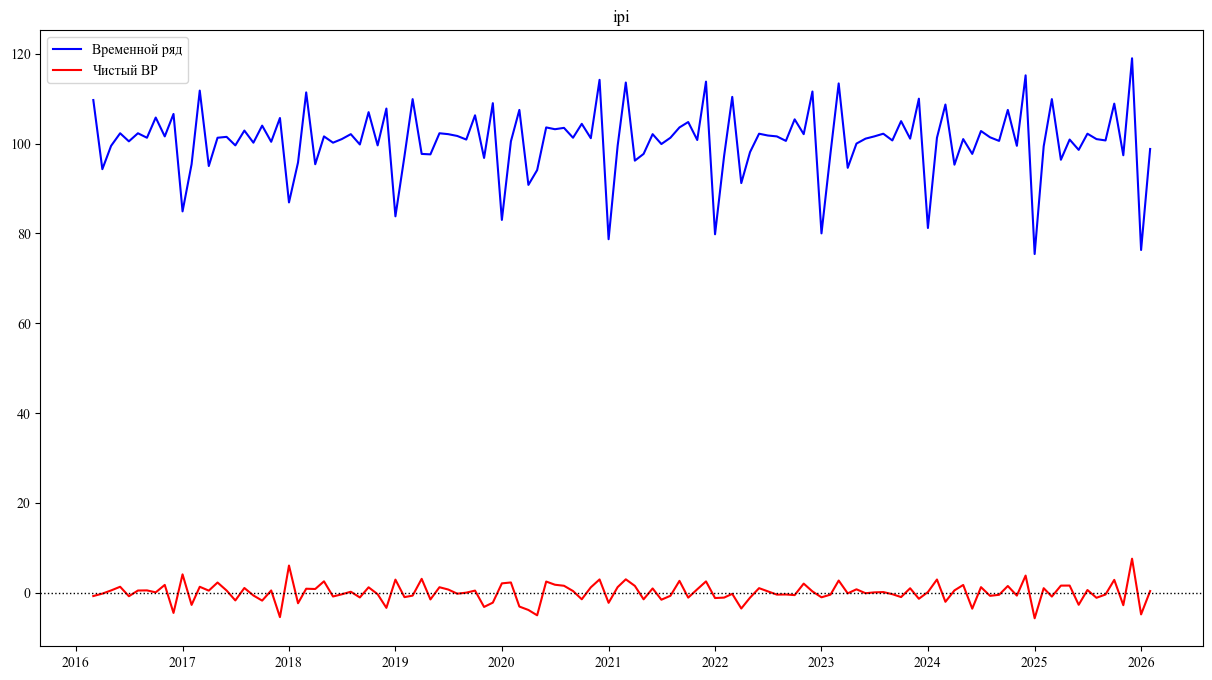

Исходный ряд ipi оказался стационарным


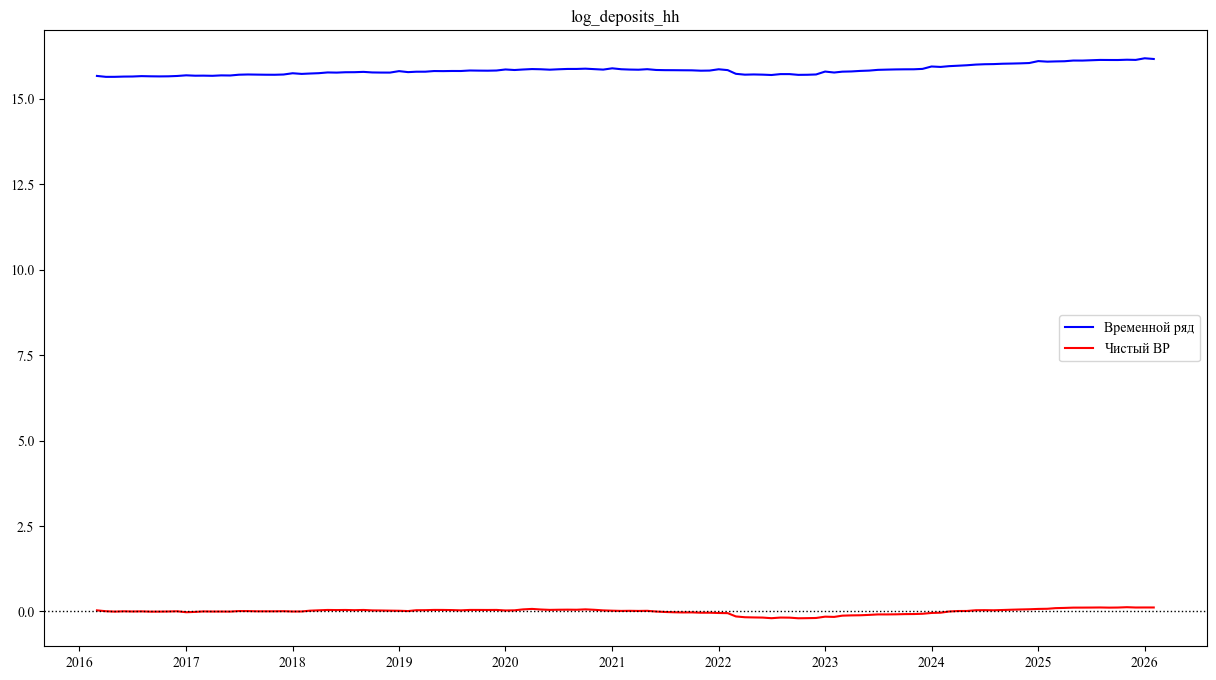

Исходный ряд log_deposits_hh оказался стационарным


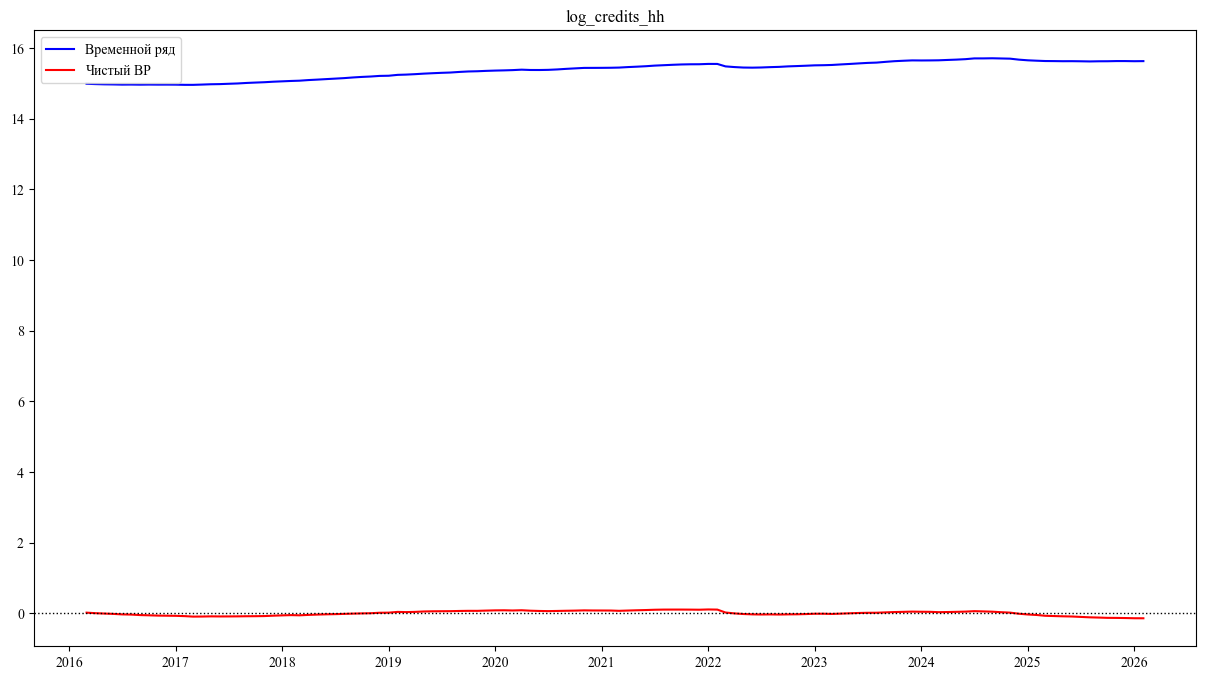

Исходный ряд log_credits_hh оказался стационарным


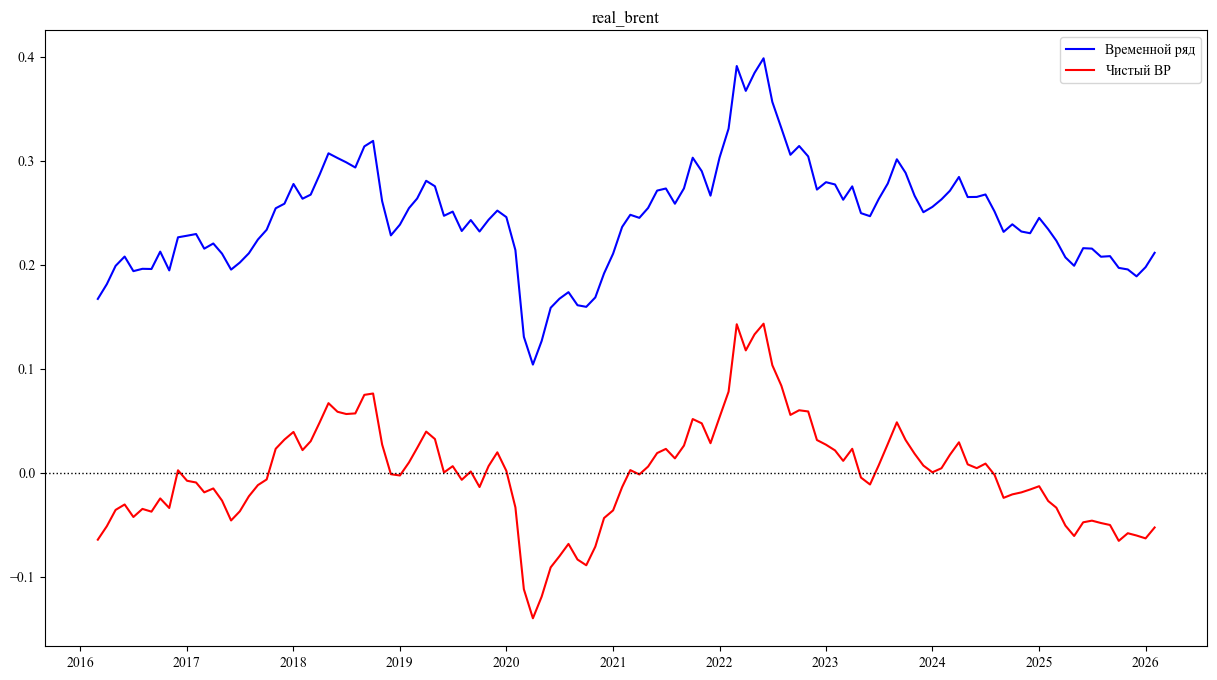

Исходный ряд real_brent оказался стационарным


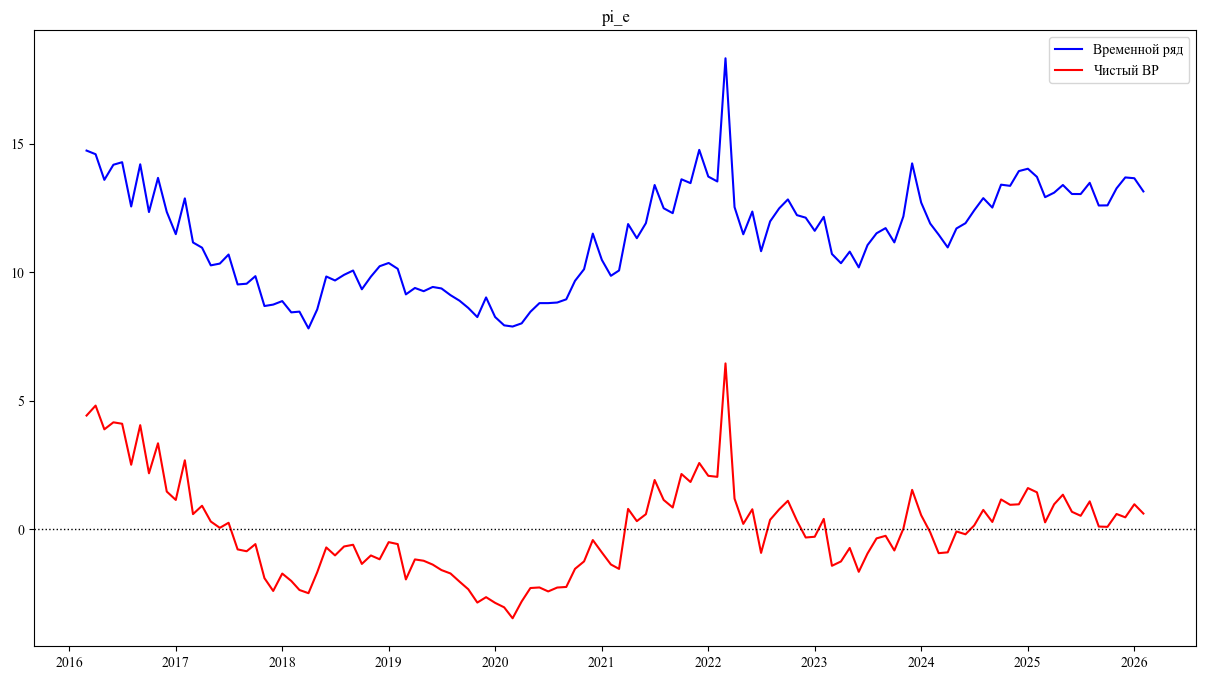

Исходный ряд pi_e оказался стационарным
Обрати внимание, что для переменной var_name есть пробел в данных
между 53 и 48 наблюдениями длинной больше 2


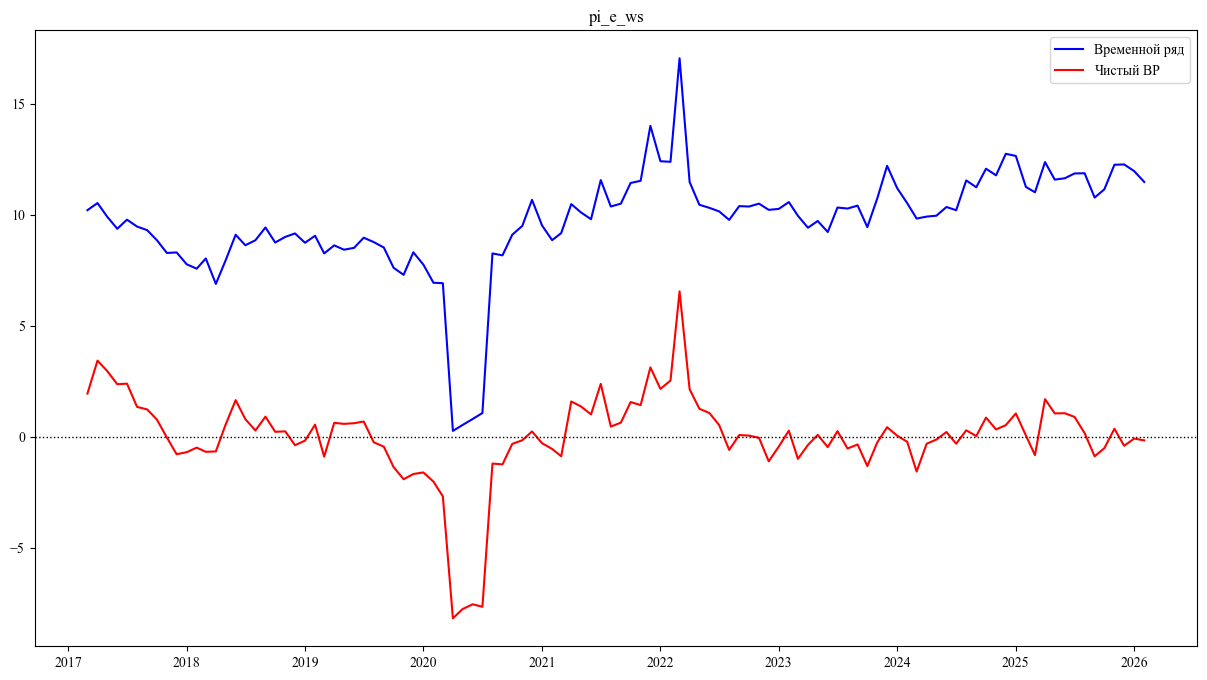

Исходный ряд pi_e_ws оказался стационарным
Обрати внимание, что для переменной var_name есть пробел в данных
между 53 и 48 наблюдениями длинной больше 2


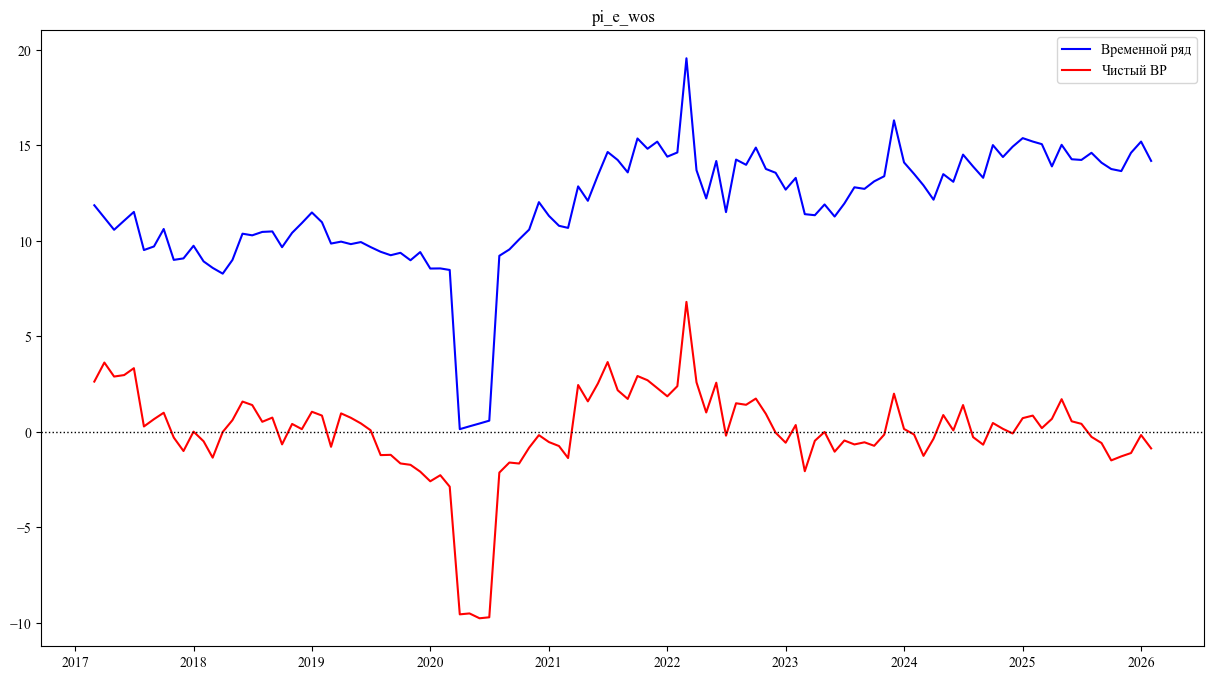

Исходный ряд pi_e_wos оказался стационарным


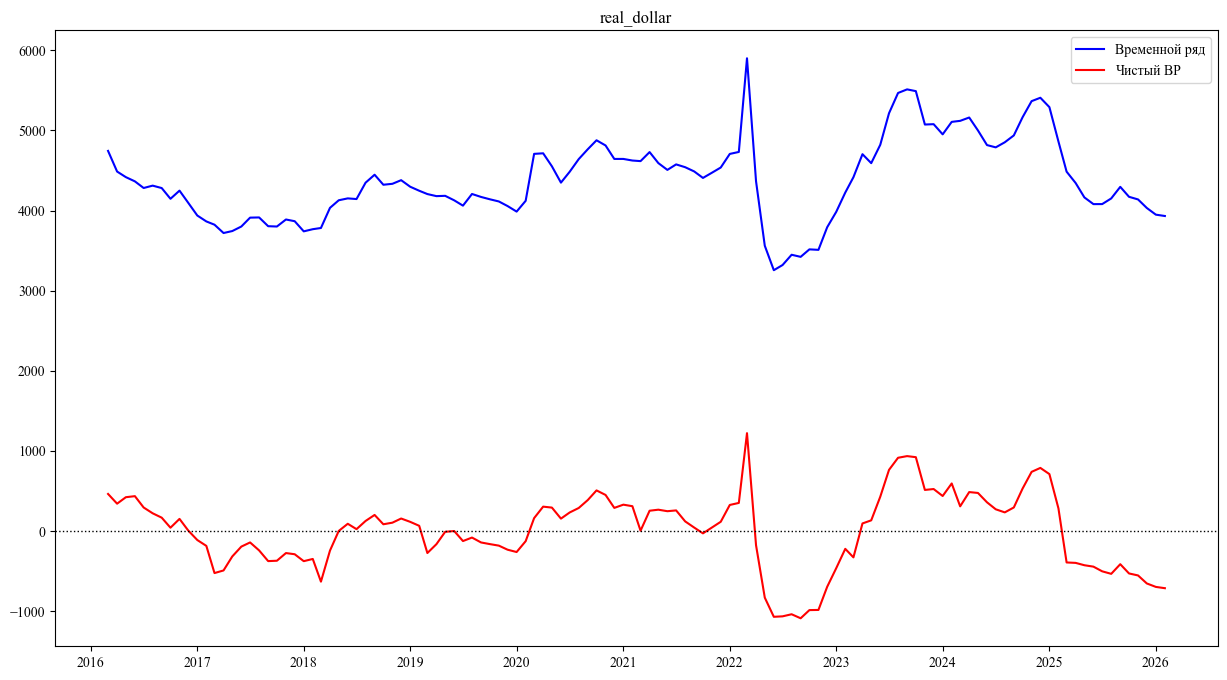

Исходный ряд real_dollar оказался стационарным


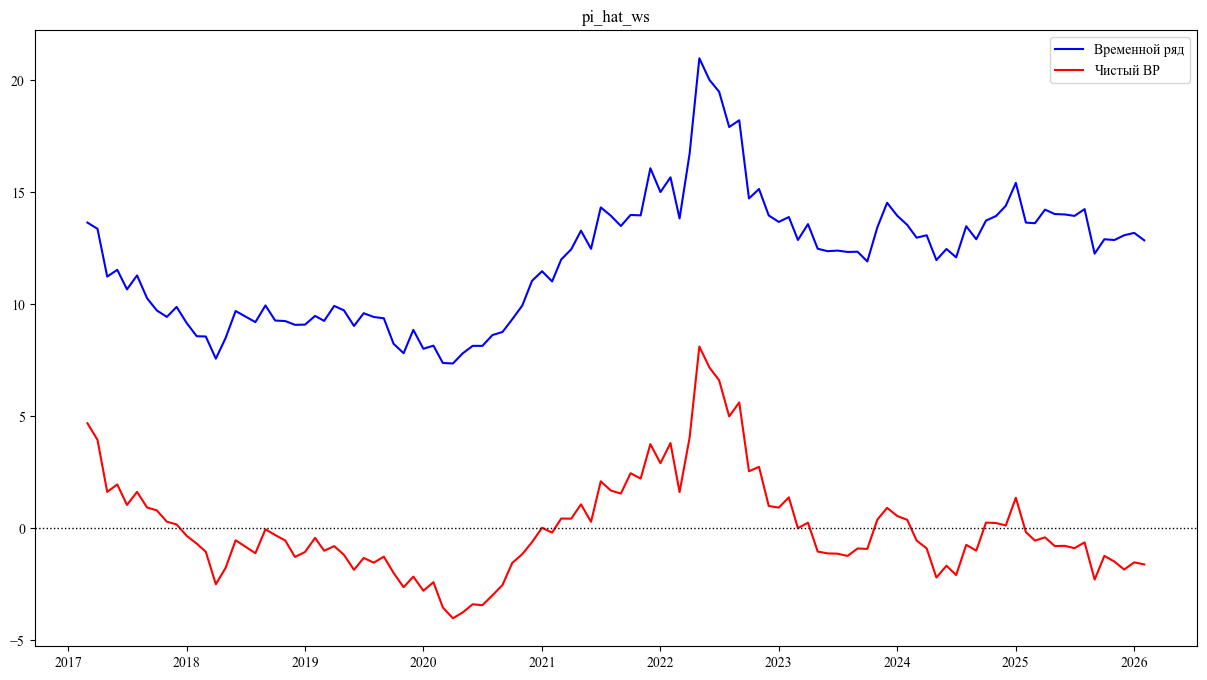

Исходный ряд pi_hat_ws оказался стационарным


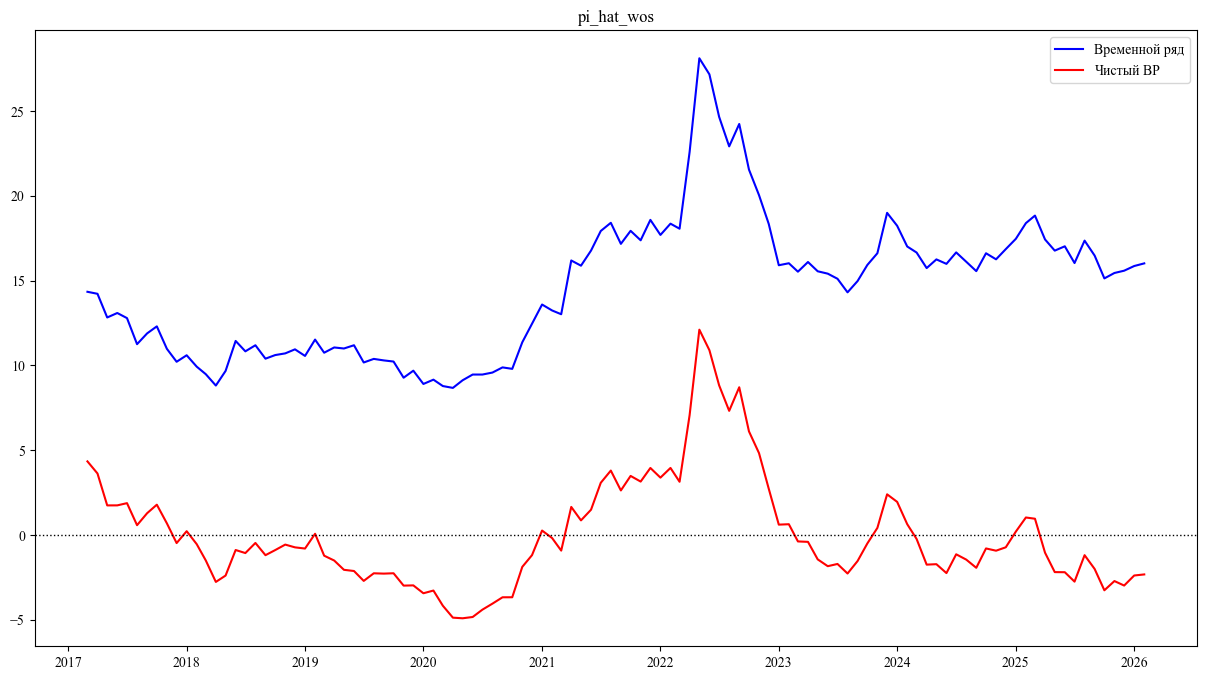

Исходный ряд pi_hat_wos оказался стационарным


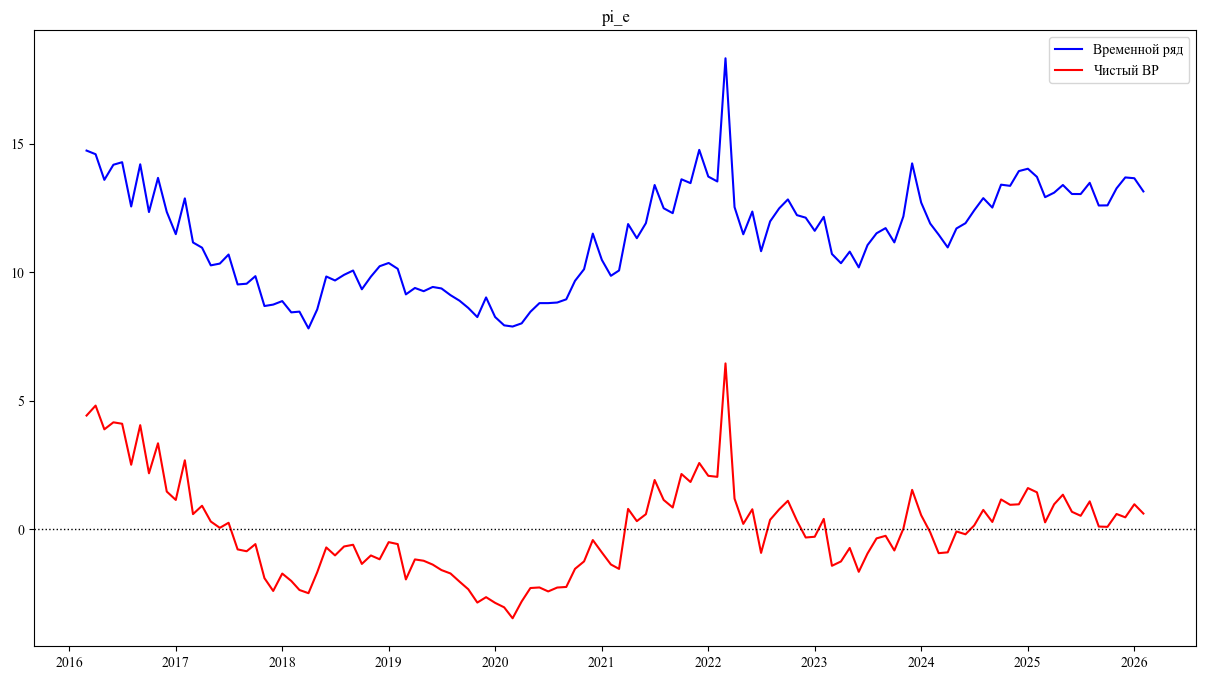

Исходный ряд pi_e оказался стационарным
Обрати внимание, что для переменной var_name есть пробел в данных
между 53 и 48 наблюдениями длинной больше 2


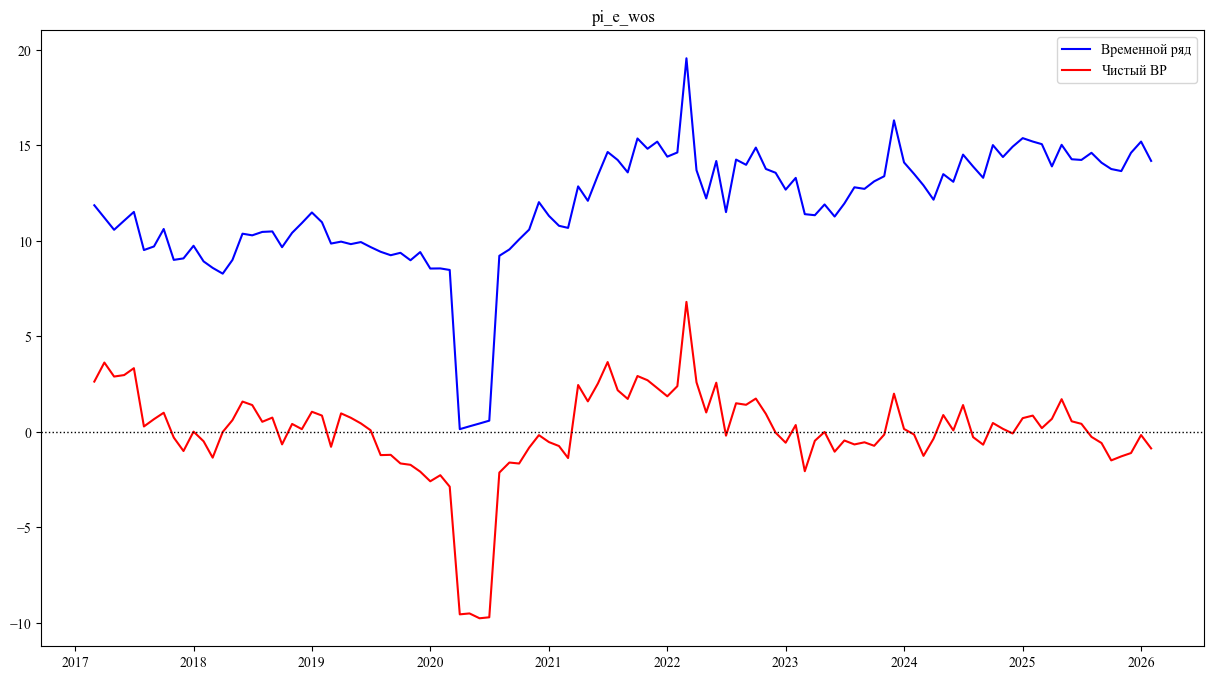

Исходный ряд pi_e_wos оказался стационарным
Обрати внимание, что для переменной var_name есть пробел в данных
между 53 и 48 наблюдениями длинной больше 2


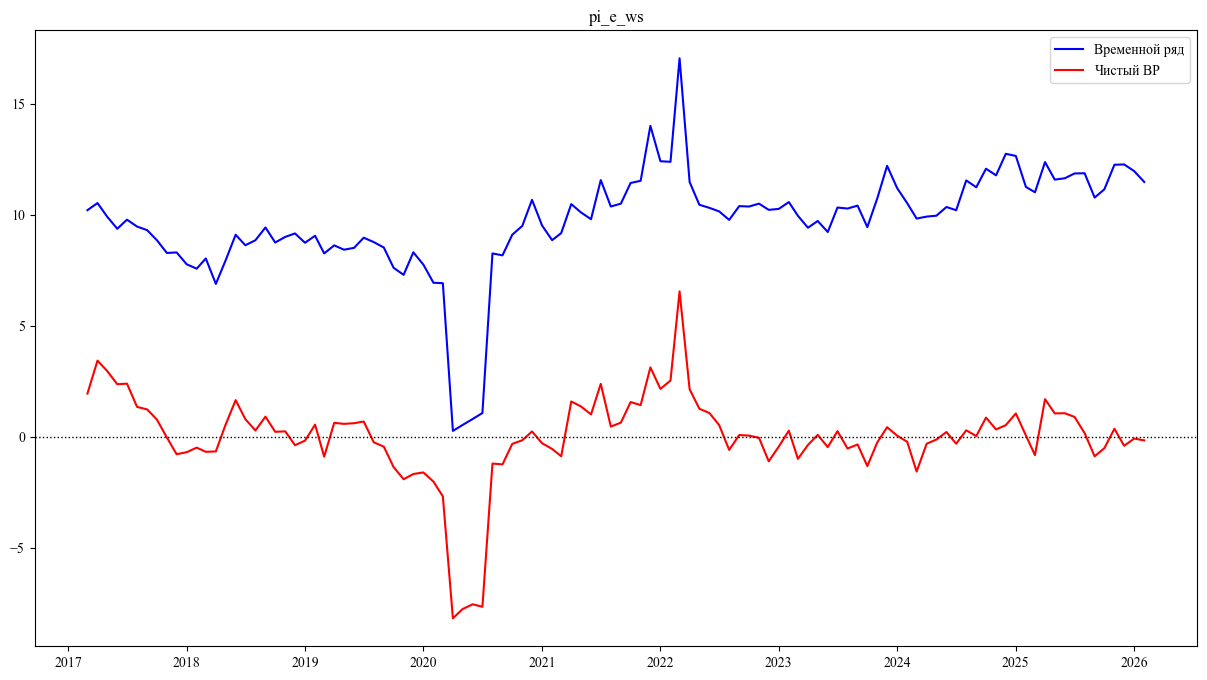

Исходный ряд pi_e_ws оказался стационарным


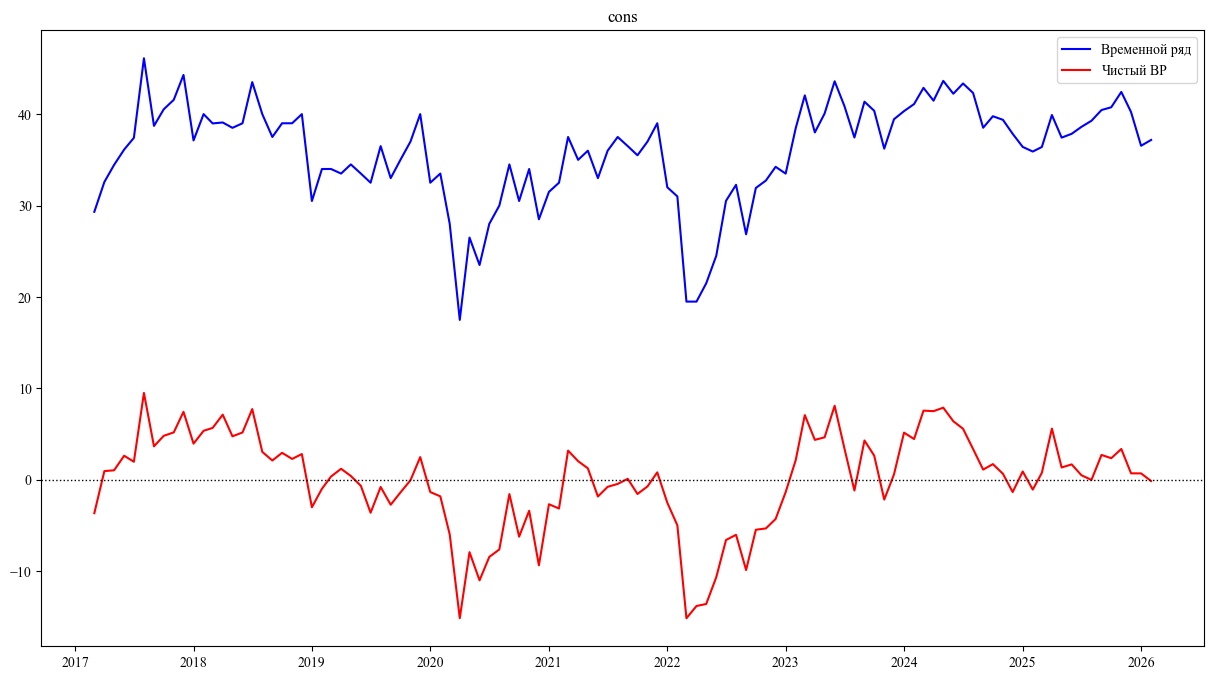

Исходный ряд cons оказался стационарным


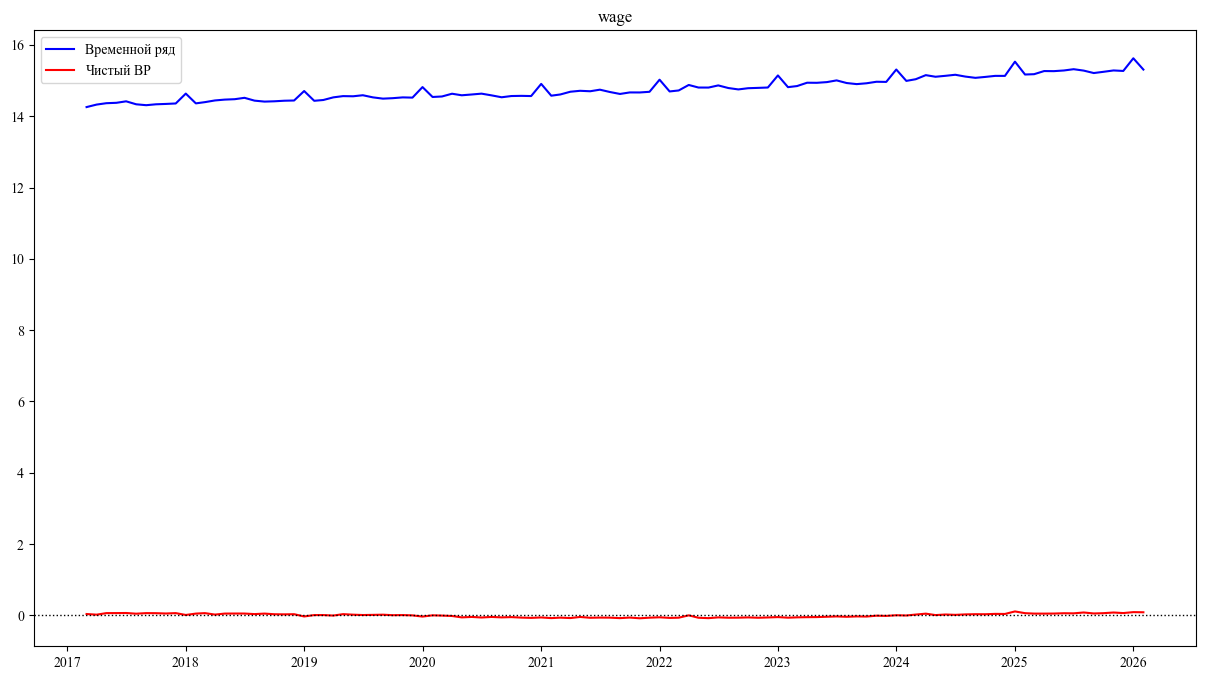

Исходный ряд wage оказался стационарным


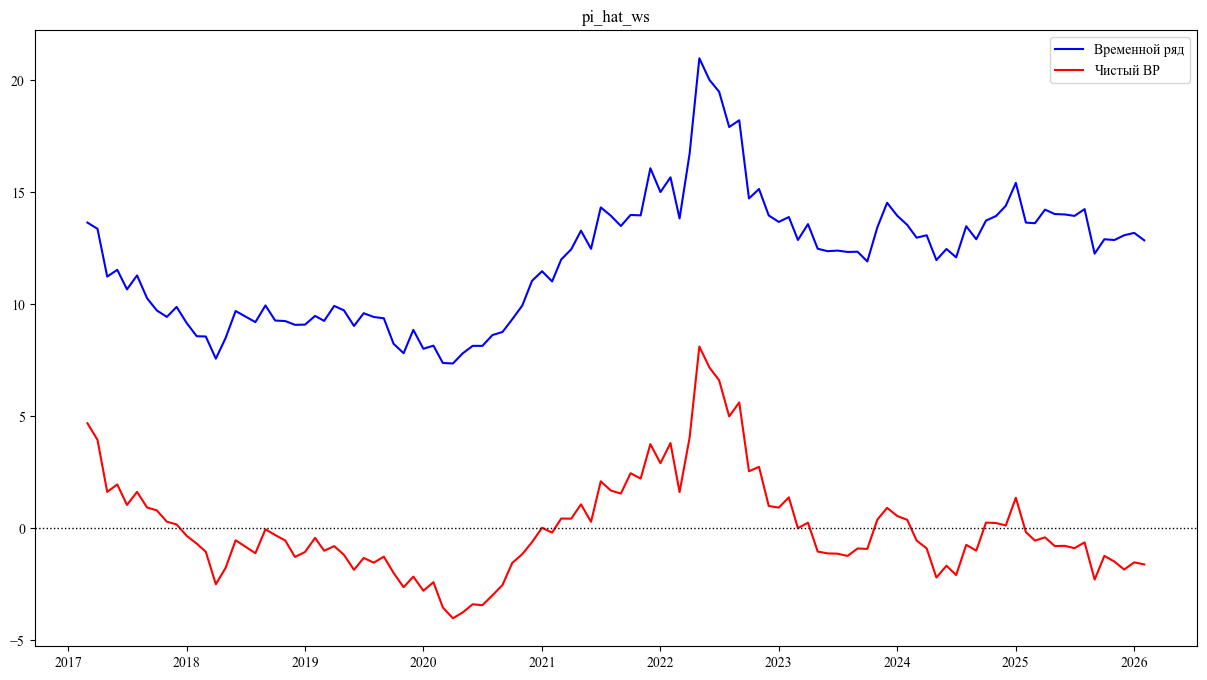

Исходный ряд pi_hat_ws оказался стационарным


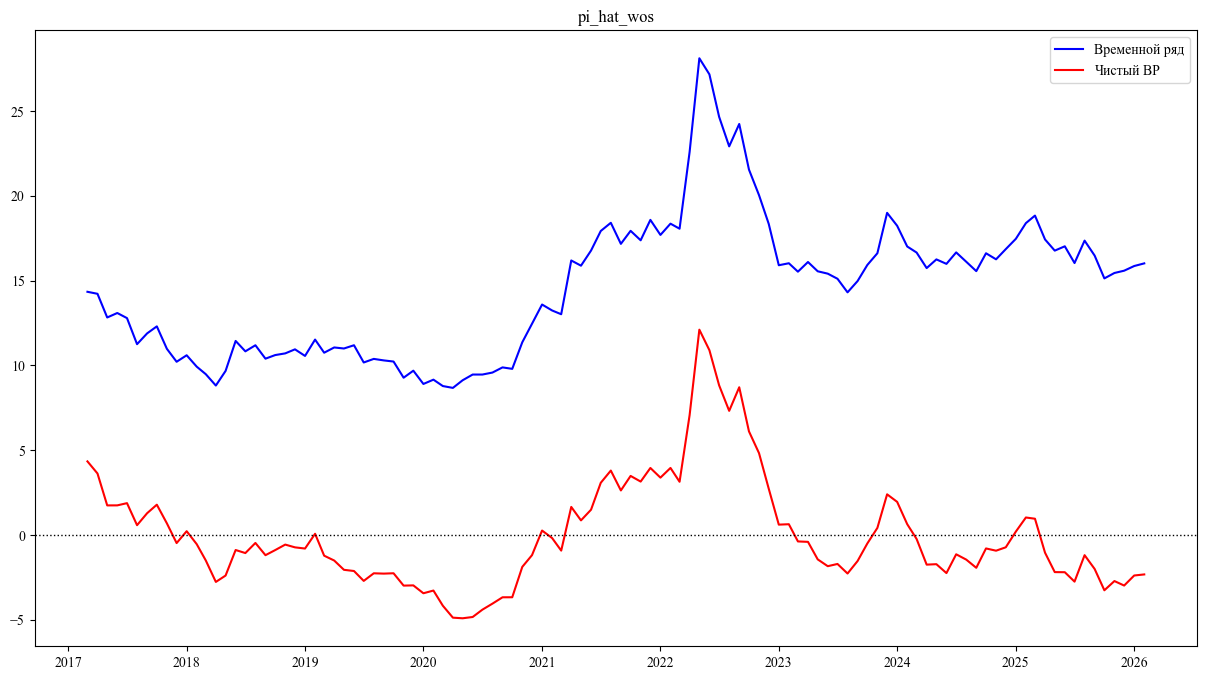

Исходный ряд pi_hat_wos оказался стационарным
Уровни не переданны, использовал единичный вектор
Уровни не переданны, использовал единичный вектор
Уровни не переданны, использовал единичный вектор
Уровни не переданны, использовал единичный вектор
Уровни не переданны, использовал единичный вектор
Уровни не переданны, использовал единичный вектор
Уровни не переданны, использовал единичный вектор
Уровни не переданны, использовал единичный вектор
Уровни не переданны, использовал единичный вектор
Уровни не переданны, использовал единичный вектор
Уровни не переданны, использовал единичный вектор
Уровни не переданны, использовал единичный вектор
Уровни не переданны, использовал единичный вектор
Уровни не переданны, использовал единичный вектор
Уровни не переданны, использовал единичный вектор


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime as dt
import sys

import pickle
filename = 'data/monthly_data.pkl'
with open(filename, 'rb') as f:
    monthly_data = pickle.load(f)
sd_df = pd.read_excel('data/pi_e/s_d.xlsx')

from structuralvar import Clean, SVAR_KL
var_spec_pie = Clean(monthly_data.loc[(monthly_data.index > dt(2016, 2, 1)) & (monthly_data.index < dt(2026, 3, 1)),
                                   ['pi_e', 'pi_e_wos', 'pi_e_ws', 'cons', 'wage', 'pi_hat_ws', 'pi_hat_wos']])
raw_data = monthly_data.loc[(monthly_data.index > dt(2016, 2, 1)) & (monthly_data.index < dt(2026, 3, 1)),
                                   ['ru_cpi', 'real_ruonia', 'ipi', 'log_deposits_hh', 'log_credits_hh',
                                     'real_brent', 'pi_e', 'pi_e_ws', 'pi_e_wos', 'real_dollar', 'pi_hat_ws', 'pi_hat_wos']]
var_spec = Clean(raw_data)

df, data = var_spec.LOS(use_harmonics=False, only_KPSS = True, hp_filter_map={'ru_cpi':True})
df_pie, data_pie = var_spec_pie.LOS(use_harmonics=False, only_KPSS = True)

covid_start, duration_covid = (data.T.index < dt(2020, 3, 1)).sum(), 5
svo_start, svo_duration = (data.T.index < dt(2022, 2, 1)).sum(), 2


base_level = {'ru_cpi':raw_data['ru_cpi'].abs().mean().item()*100, 
              'real_ruonia':1, 
              'ipi':raw_data['ipi'].abs().mean().item(),
              'pi_e_wos':raw_data['pi_e_wos'].abs().mean().item()}
lag = 2

endog_names_pie_general = ['wage', 'cons']
endog_names_pie_special = ['pi_e', 'pi_e_ws', 'pi_e_wos', 'pi_hat_ws', 'pi_hat_wos']
results = {}
for var in endog_names_pie_special:
    df_endog = data_pie.loc[endog_names_pie_general + [var], :].copy()
    df_endog = df_endog.loc[:,df_endog.columns < dt(2020, 4, 1)].copy()   # K×T

    model = SVAR_KL(
        data=df_endog,
        p=lag,
        layout="KL_KxT",
        time_order="chronological",
        add_const=True,
        u_dict = ['шок доходов', 'шок оптимизма', 'шок ОИ'],
        y_dict = ['Объем фонда зарплаты (логарифм)', 'индекс оптимизма', 'инфляционные ожидания']
    ).fit_ols()
    A_hat = model.A_hat
    p = model.p
    K = model.K
    
    unknown_mask = np.array([False, False, True])  

    known_future = data_pie.loc[endog_names_pie_general, :].copy().loc[:,
                        (data_pie.columns > dt(2020, 3, 1)) & (data_pie.columns < dt(2020, 8, 1))]
    res = []
    horizon = known_future.shape[1]
    counter = 0
    future = pd.DataFrame(columns=known_future.columns)
    for i, b in enumerate(unknown_mask):
        
        if not b:
            future.loc[known_future.index.to_list()[i-counter]] = known_future.iloc[i-counter]
        else:
            counter += 1
            future.loc[var] = np.zeros(horizon)    
    for h in range(horizon):
        if h == 0:
            X = model.Z[:, -1]
            
        else:
            
            X = np.hstack([np.array([1]), future.iloc[:, h-1].to_numpy(), X[1:-(K)]])
        y_hat = (A_hat @ X)[unknown_mask]
        future.loc[unknown_mask, future.columns[h]] = y_hat.item()
    results[var] = future.loc[unknown_mask, :]

for var in results:
    data.loc[var,(data.columns > dt(2020, 3, 1)) & (data.columns < dt(2020, 8, 1))] = results[var].to_numpy()


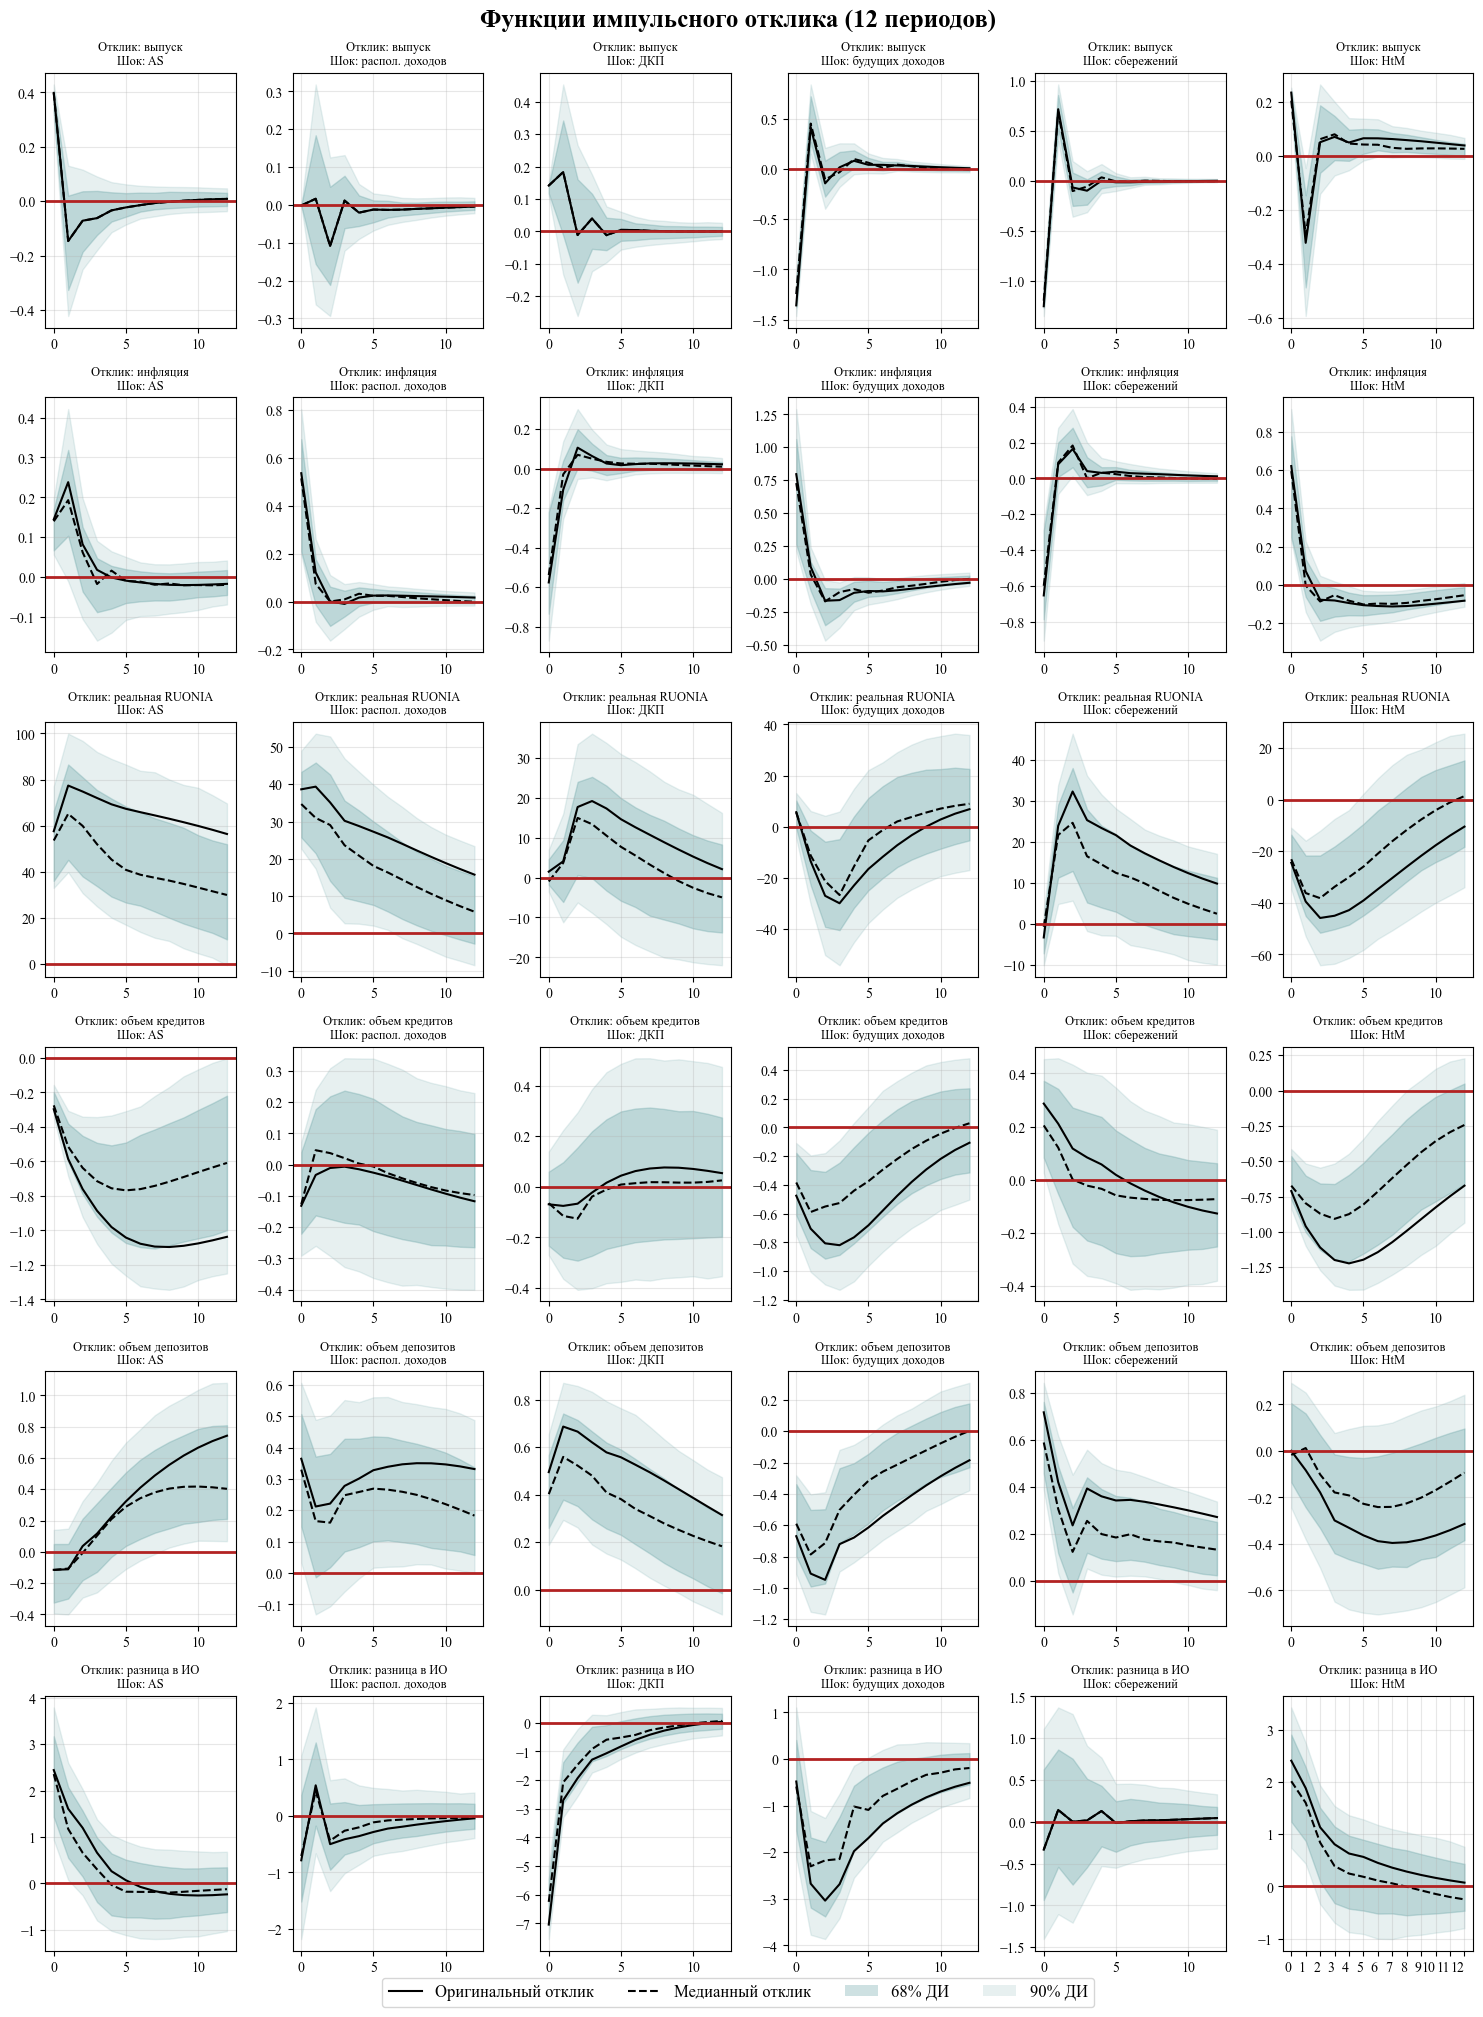

,AS,распол. доходов,ДКП,будущих доходов,сбережений,HtM
выпуск,0.960,0.004,0.405,-0.831,-0.602,0.812
инфляция,-0.216,0.398,-0.130,-0.027,-0.135,-0.494
реальная RUONIA,19.828,5.286,0.001,0.916,3.406,-1.273
объем кредитов,-0.466,-0.070,0.012,-0.080,-0.050,-0.228
объем депозитов,0.313,0.100,0.068,-0.047,0.089,-0.010
разница в ИО,1.186,-0.092,-1.771,-2.598,0.246,1.029


In [2]:

short_run_anchor = [
    (0, 0, 1, 0, 100),
    (0, 4, 5, 0, 10),
    (0, 4, 5, 1, 10),

]
long_run_anchor = [
    (0, 2, 2, 1),
    (0, 4, 5, 1),
    (0, 0, 1, 1),
    (0, 0, 1, 1),
]
short_run_signs = [
    (0, 1, 2, False, 0, 100),
    (0, 1, 2, False, 1, 100),
    (0, 1, 2, False, 2, 50),
    (0, 1, 3, True, 0, 4),
    (0, 0, 2, False, 0, 10),
    (0, 5, 1, False, 0, 1),
    (0, 5, 3, False, 0, 1),
    (0, 2, 4, False, 0, 1),

    (0, 3, 1, False, 0, 1),
    (0, 1, 1, True, 0, 1),
    (0, 0, 1, True, 1, 1),



    (0, 0, 0, True, 0, 1),
    (0, 1, 1, True, 0, 1),
    (0, 2, 2, True, 0, 10),
    (0, 3, 3, True, 0, 1),
    (0, 4, 4, True, 0, 1),
    (0, 5, 5, True, 0, 1),
]
long_run_signs = [
    (0, 3, 5, False, 1),
    (0, 2, 1, True, 1),
    (0, 1, 2, False, 10),
    (0, 0, 0, True, 1),
    (0, 0, 1, True, 1),
    (0, 3, 2, False, 1),
    (0, 4, 4, True, 1),
    (0, 5, 5, True, 1)
]
lag = 2

endog_names = ['ipi', 'ru_cpi', 'real_ruonia', 'log_credits_hh', 'log_deposits_hh', 'pi_e_wos']
exog_names  = ['real_brent']

df_endog = data.loc[endog_names, :]   # K×T
df_exog  = data.loc[exog_names, :]    # K_ex×T

model = SVAR_KL(
    data=df_endog,
    p=lag,
    exog=df_exog,              #
    layout="KL_KxT",
    time_order="chronological",
    add_const=True,
    log_vars = ['log_credits_hh', 'log_deposits_hh'],
    u_dict = ['AS', 'распол. доходов', 'ДКП', 'будущих доходов', 'сбережений', 'HtM'],
    y_dict = ['выпуск', 'инфляция', 'реальная RUONIA', 
              'объем кредитов', 'объем депозитов', 'разница в ИО'],
    base_levels=base_level
).fit_ols()

rr = model.identify_combined(
    short_run_anchor=short_run_anchor,
    long_run_anchor=long_run_anchor,
    short_run_signs=short_run_signs,
    long_run_signs=long_run_signs,
    n_starts=100,
    seed=100,
    method="BFGS",
)

horizon = 120
irf0 = model.irf(horizon=horizon)   # (horizon+1, K, K)
required = 1000

irf_draws = model.irf_bootstrap(
    horizon=horizon,
    n_boot=required-1,
    seed=1,
    scheme="fixed_Q",
)

irf_sims = [irf0] + [irf_draws[b] for b in range(irf_draws.shape[0])]
model.plot_irfs_grid(irf_sims=irf_sims,
                     horizon_plot=12,
                     main_color='cadetblue', 
                     figsize = (15, 20))

model.print_upsilon()

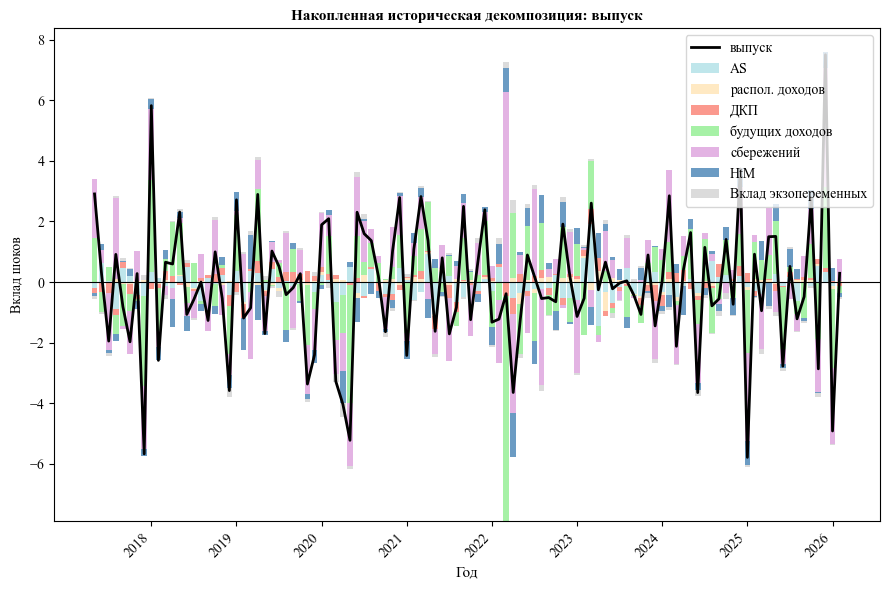

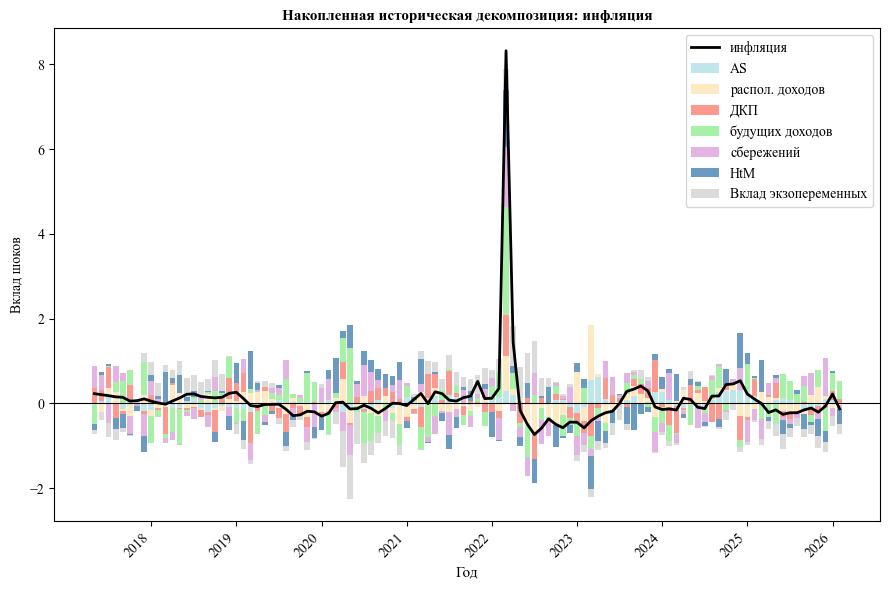

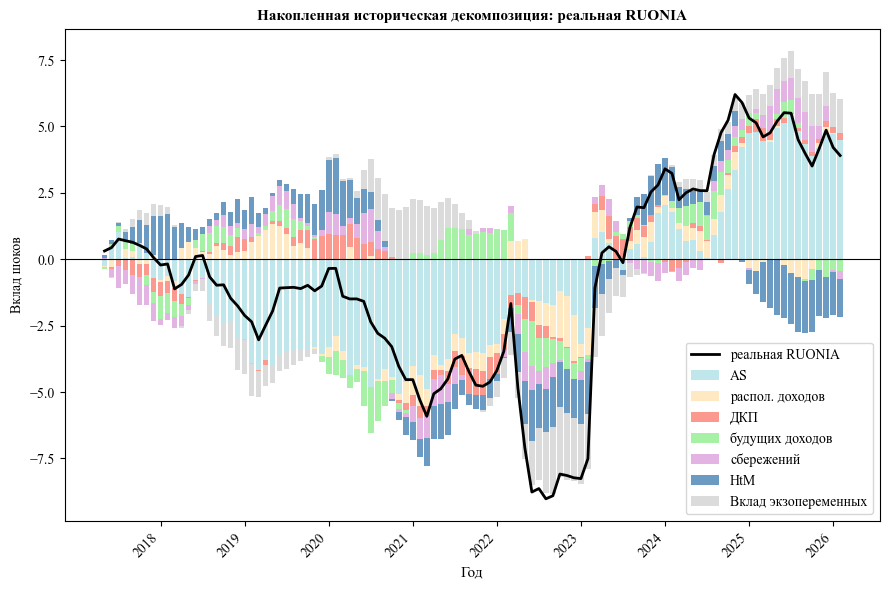

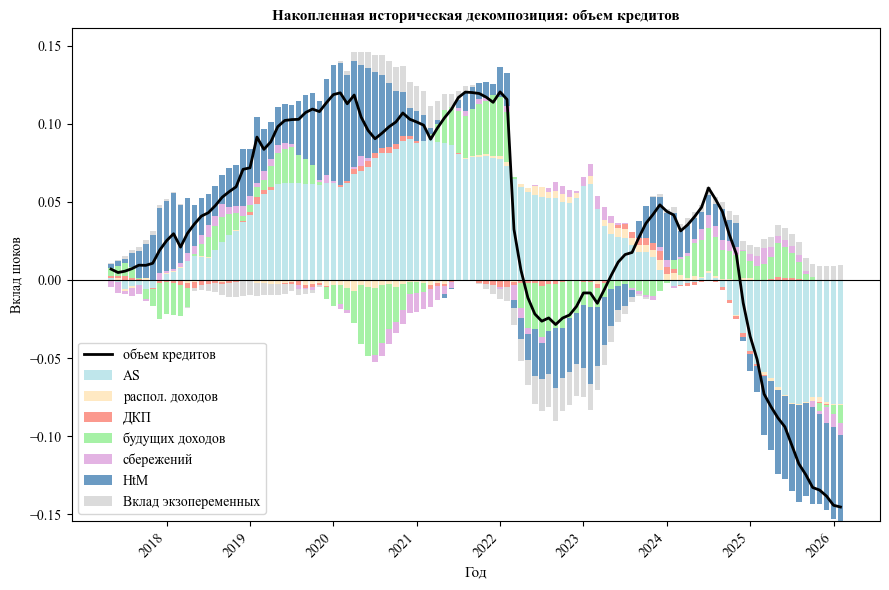

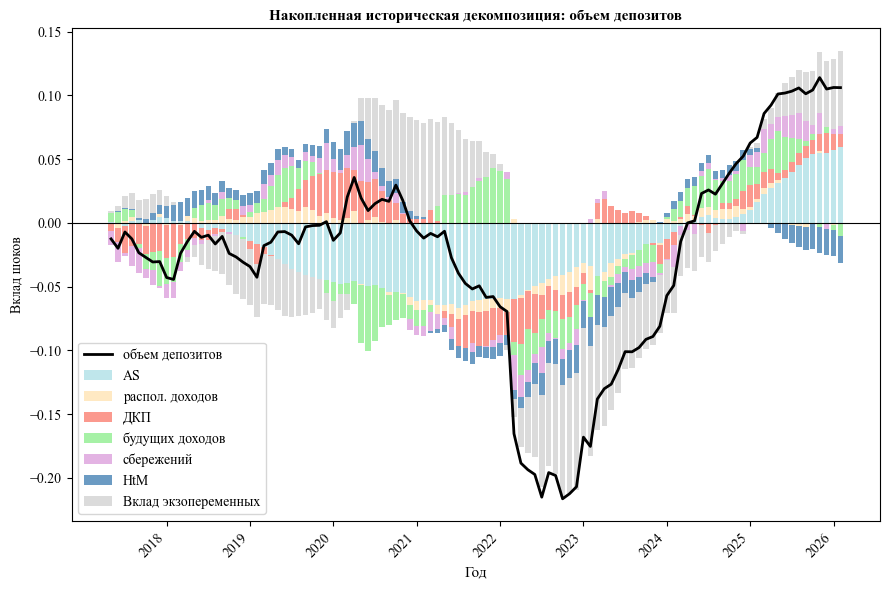

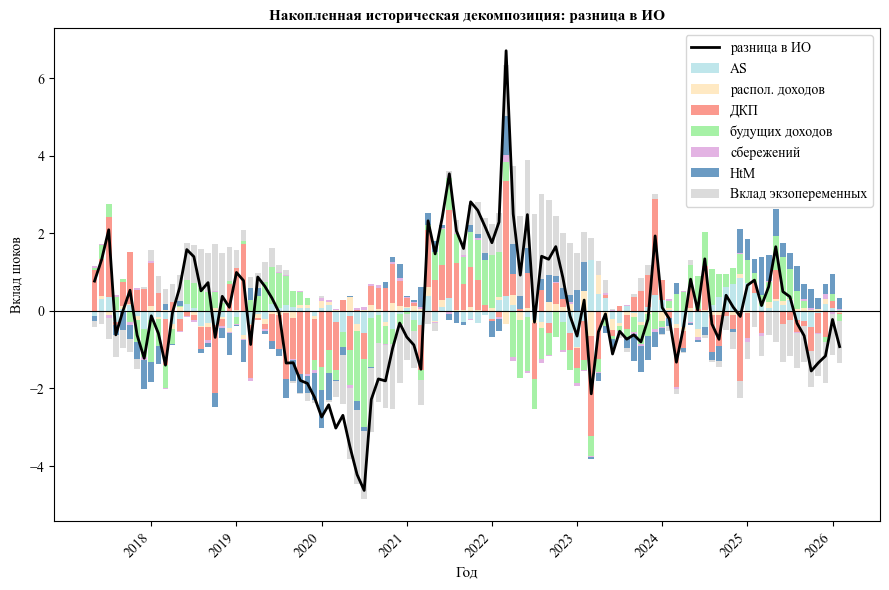

In [4]:
hd, contrib_df = model.historical_decomposition(plot_hd=True,
                                    init_clean = True,
                                    exog_clean = False,
                                    const_clean = True)

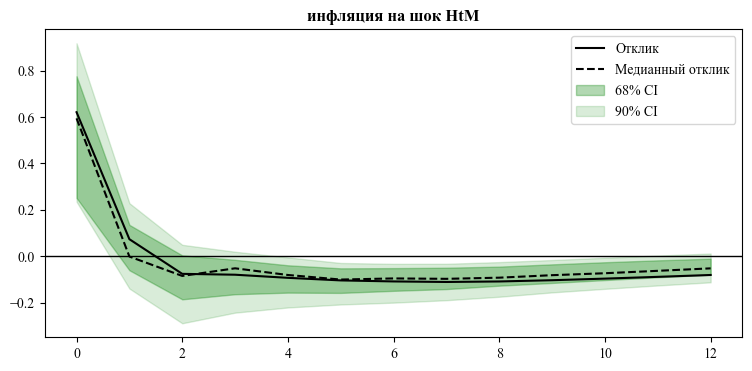

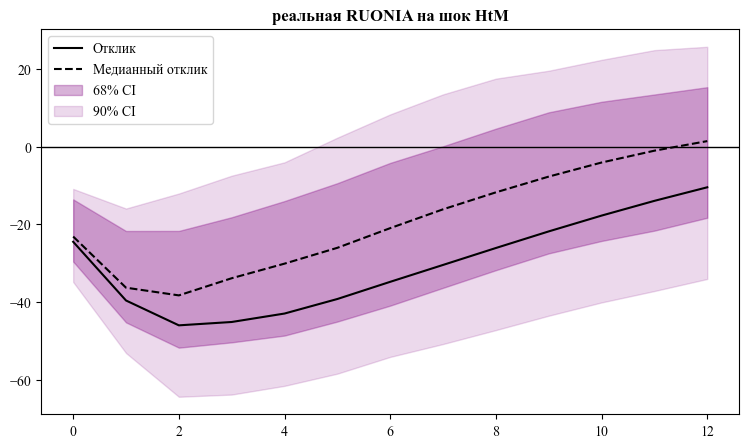

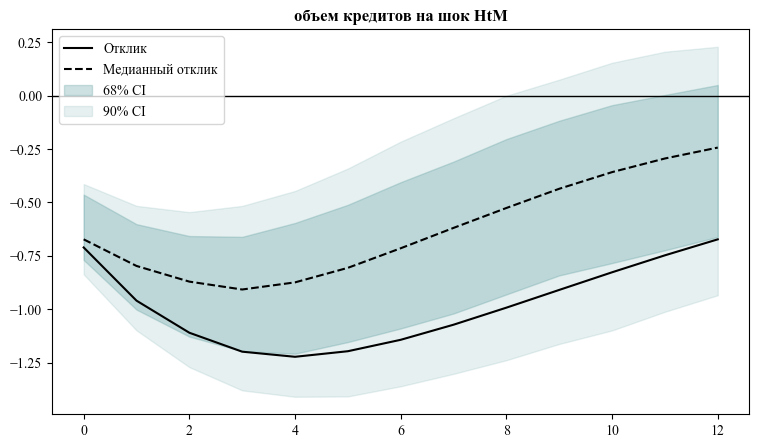

In [5]:
model.plot_single_irf(irf_sims = irf_sims,
                      horizon=12,
                      variable='ru_cpi',
                      shock = 'HtM',
                      ci_color = 'green',
                      plot_simulations = False,
                      figsize = (9,4))
model.plot_single_irf(irf_sims = irf_sims,
                      horizon=12,
                      variable='real_ruonia',
                      shock = 'HtM',
                      ci_color = 'purple',
                      plot_simulations = False)
model.plot_single_irf(irf_sims = irf_sims,
                      horizon=12,
                      variable='log_credits_hh',
                      shock = 'HtM',
                      ci_color = 'cadetblue',
                      plot_simulations = False)